# 11. CVAE + Perceptual Loss — Idle 전용 학습 (PyTorch)

모든 카테고리(몸/헤어/상의/하의/발)의 idle 프레임만 학습하는 단일 CVAE+PL 모델.

| 항목 | 내용 |
|------|------|
| 카테고리 | body, hair, torso, legs, feet |
| 프레임 필터 | `_idle_` 포함 파일만 |
| 레이블 | `body_{type}` / `{category}_{keyword}` |
| 손실함수 | MSE + Perceptual(VGG16) + KL |
| 체크포인트 | `checkpoints_cvae_pl_idle_pt/` |

## 1. 환경 설정

In [18]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_ROOT  = Path('dataset/processed')
CKPT_DIR   = Path('checkpoints_cvae_pl_idle_pt')
CKPT_DIR.mkdir(exist_ok=True)

BODY_TYPES   = ['child', 'female', 'male', 'muscular', 'pregnant', 'teen']
LAYER_CATS   = ['hair', 'torso', 'legs', 'feet']
MAX_PER_CLASS = None  # None=전체, 정수 지정 시 클래스당 최대 샘플 수

CFG = {
    'latent_dim'   : 128,
    'base_channels': 32,
    'channels'     : 4,
    'epochs'       : 100,
    'batch_size'   : 128,
    'lr'           : 1e-3,
    'beta'         : 1.5,
    'lambda_perc'  : 1.0,
    'patience'     : 10,
    'val_ratio'    : 0.1,
}
print('CFG:', CFG)

Device: mps
CFG: {'latent_dim': 128, 'base_channels': 32, 'channels': 4, 'epochs': 100, 'batch_size': 128, 'lr': 0.001, 'beta': 1.5, 'lambda_perc': 1.0, 'patience': 10, 'val_ratio': 0.1}


## 2. 데이터 스캔 & 레이블 구성

In [19]:
samples = []  # (path, label_idx)
label_names = []
label_map   = {}

def add_label(name):
    if name not in label_map:
        label_map[name] = len(label_names)
        label_names.append(name)
    return label_map[name]

# ── body: bodies_{type}_*_idle_* 또는 {type}_idle_* ──────────────────
body_dir = DATA_ROOT / 'body'
body_idle_files = [f for f in body_dir.glob('*.png') if '_idle_' in f.name]

body_counter = Counter()
for fp in body_idle_files:
    stem   = fp.name.replace('bodies_', '')
    btype  = stem.split('_')[0]
    if btype not in BODY_TYPES:
        continue
    label  = f'body_{btype}'
    body_counter[label] += 1
    idx = add_label(label)
    samples.append((fp, idx))

print(f'body: {len(body_idle_files)} idle files → {len(body_counter)} classes')
for k, v in sorted(body_counter.items()):
    print(f'  {k}: {v}')

# ── layer categories: hair / torso / legs / feet ─────────────────────
for cat in LAYER_CATS:
    cat_dir = DATA_ROOT / cat
    cat_total = 0
    for kw_dir in sorted(cat_dir.iterdir()):
        if not kw_dir.is_dir():
            continue
        idle_files = [f for f in kw_dir.glob('*.png') if '_idle_' in f.name]
        if not idle_files:
            continue
        label = f'{cat}_{kw_dir.name}'
        idx   = add_label(label)
        for fp in idle_files:
            samples.append((fp, idx))
        cat_total += len(idle_files)
    print(f'{cat}: {cat_total} idle files')

CFG['num_classes'] = len(label_names)
print(f'\n총 샘플: {len(samples):,}  총 클래스: {CFG["num_classes"]}')
print('label_names (first 10):', label_names[:10])

body: 256 idle files → 6 classes
  body_child: 32
  body_female: 48
  body_male: 48
  body_muscular: 32
  body_pregnant: 48
  body_teen: 48
hair: 1916 idle files
torso: 6218 idle files
legs: 10400 idle files
feet: 13784 idle files

총 샘플: 32,574  총 클래스: 89
label_names (first 10): ['body_pregnant', 'body_female', 'body_teen', 'body_male', 'body_child', 'body_muscular', 'hair_afro', 'hair_balding', 'hair_bangs', 'hair_bangslong']


## 3. 클래스 분포 분석

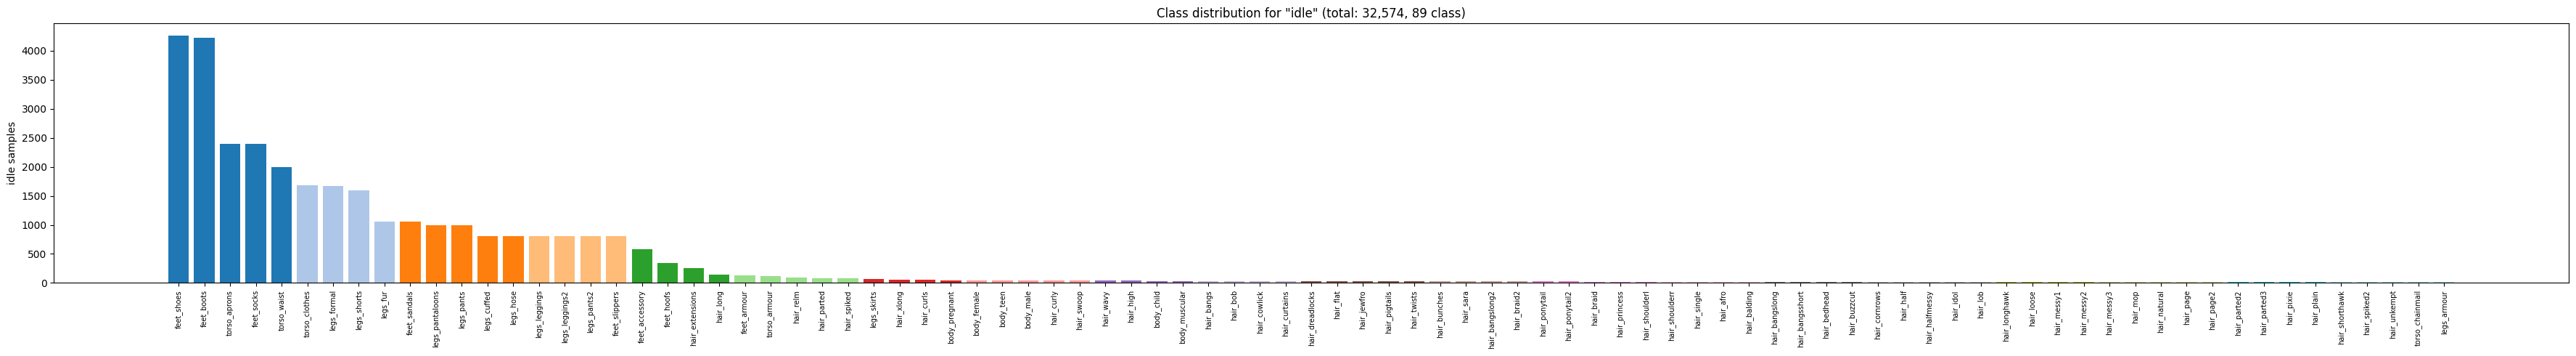

Max: 4256  Min: 16  Mean: 366.0


In [20]:
counter = Counter(label_names[idx] for _, idx in samples)

fig, ax = plt.subplots(figsize=(max(14, CFG['num_classes'] * 0.4), 5))
names  = [n for n, _ in counter.most_common()]
counts = [c for _, c in counter.most_common()]
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
ax.bar(range(len(names)), counts, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.set_ylabel('idle samples')
ax.set_title(f'Class distribution for "idle" (total: {len(samples):,}, {CFG["num_classes"]} class)')
plt.tight_layout()
plt.show()

print(f'Max: {max(counts)}  Min: {min(counts)}  Mean: {np.mean(counts):.1f}')

## 4. Dataset & DataLoader

train: 29,317  val: 3,257


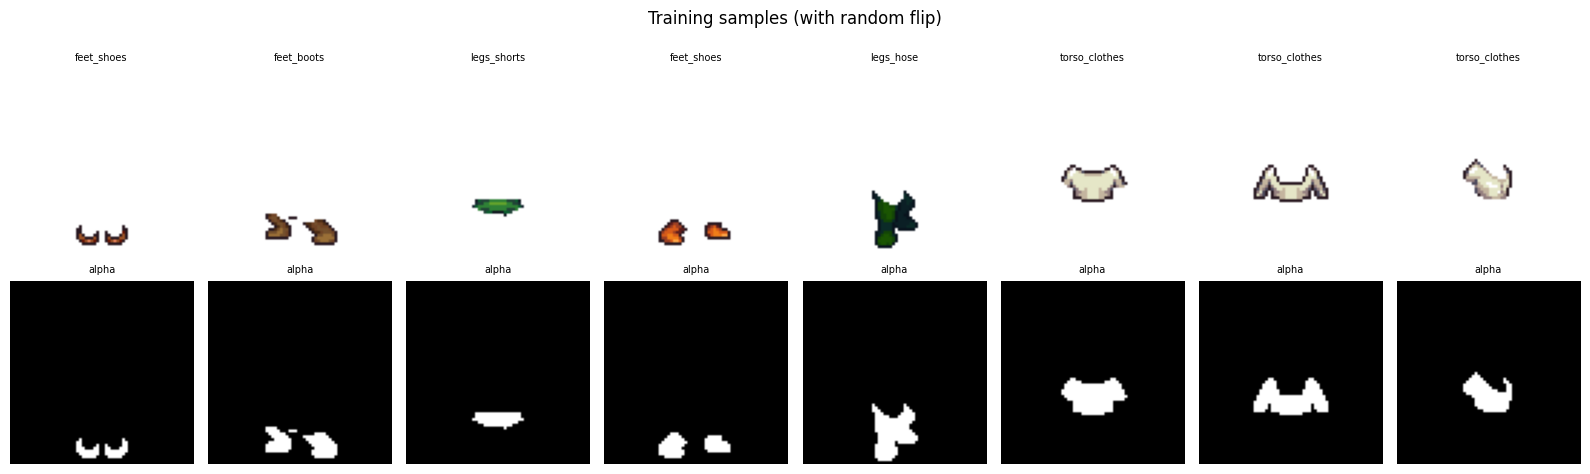

In [21]:
# MAX_PER_CLASS 적용
if MAX_PER_CLASS is not None:
    per_class = {}
    filtered = []
    for fp, idx in samples:
        if per_class.get(idx, 0) < MAX_PER_CLASS:
            filtered.append((fp, idx))
            per_class[idx] = per_class.get(idx, 0) + 1
    samples = filtered
    print(f'MAX_PER_CLASS={MAX_PER_CLASS} 적용 후: {len(samples):,}')

NUM_CLASSES = CFG['num_classes']

# train: 좌우반전 augmentation 포함 / val: 원본만
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
])

class IdleDataset(Dataset):
    def __init__(self, items, transform):
        self.items     = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        fp, idx = self.items[i]
        img = Image.open(fp).convert('RGBA')
        x   = self.transform(img)
        c   = F.one_hot(torch.tensor(idx), NUM_CLASSES).float()
        return x, c

# items 리스트 분할 후 transform을 달리 적용
rng = random.Random(42)
shuffled = samples[:]
rng.shuffle(shuffled)
val_size  = max(1, int(len(shuffled) * CFG['val_ratio']))
val_items = shuffled[:val_size]
tr_items  = shuffled[val_size:]

train_ds = IdleDataset(tr_items,  train_transform)
val_ds   = IdleDataset(val_items, val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

print(f'train: {len(train_ds):,}  val: {len(val_ds):,}')

# 샘플 시각화
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
xs, cs = next(iter(train_loader))
for i in range(8):
    img   = xs[i].permute(1, 2, 0).numpy()
    lbl   = cs[i].argmax().item()
    alpha = img[:, :, 3:]
    rgb   = img[:, :, :3] * alpha + (1 - alpha)
    axes[0, i].imshow(rgb)
    axes[0, i].set_title(label_names[lbl], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(img[:, :, 3], cmap='gray')
    axes[1, i].set_title('alpha', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Training samples (with random flip)')
plt.tight_layout()
plt.show()

## 5. CVAE 모델

In [22]:
LATENT_DIM  = CFG['latent_dim']
BASE_CH     = CFG['base_channels']
CHANNELS    = CFG['channels']

class CVAEEncoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        layers, in_ch, ch = [], channels, base_ch
        for _ in range(4):
            layers += [nn.Conv2d(in_ch, ch, 4, stride=2, padding=1),
                       nn.BatchNorm2d(ch, momentum=0.1), nn.LeakyReLU(0.2)]
            in_ch = ch; ch *= 2
        self.conv  = nn.Sequential(*layers)
        flat_dim   = (base_ch * 8) * 4 * 4
        self.fc_mu = nn.Linear(flat_dim + num_classes, latent_dim)
        self.fc_lv = nn.Linear(flat_dim + num_classes, latent_dim)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = torch.cat([h, c], dim=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.start_ch = base_ch * 8
        self.fc       = nn.Linear(latent_dim + num_classes, self.start_ch * 4 * 4)
        layers, in_ch = [], self.start_ch
        for i, out_ch in enumerate([base_ch*4, base_ch*2, base_ch, channels]):
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1))
            if i < 3:
                layers += [nn.BatchNorm2d(out_ch, momentum=0.1), nn.ReLU()]
            else:
                layers.append(nn.Sigmoid())
            in_ch = out_ch
        self.deconv = nn.Sequential(*layers)

    def forward(self, z, c):
        h = self.fc(torch.cat([z, c], dim=-1))
        return self.deconv(h.view(-1, self.start_ch, 4, 4))


class CVAE(nn.Module):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim, channels)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return self.decoder(z, c), mu, lv


model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'파라미터: {total_params:,}')

파라미터: 3,347,012


## 6. Perceptual Loss (VGG16)

In [23]:
class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.slice1 = vgg.features[:4]   # relu1_2 — slice2 입력용, loss 미사용
        self.slice2 = vgg.features[4:9]  # relu2_2 — loss 계산 대상
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        return self.slice2(self.slice1(x))


vgg_feat = VGGFeatures().to(DEVICE)
vgg_feat.eval()

_bgr_mean = torch.tensor([103.939, 116.779, 123.68]).view(1, 3, 1, 1).to(DEVICE)

def to_vgg_scaled(img_rgba):
    """RGBA [0,1] → white composite RGB → [0,255] BGR → subtract ImageNet BGR means"""
    rgb   = img_rgba[:, :3]
    alpha = img_rgba[:, 3:4]
    rgb   = rgb * alpha + (1.0 - alpha)
    bgr   = rgb[:, [2, 1, 0]] * 255.0
    return bgr - _bgr_mean


def perceptual_loss(real, fake):
    r2 = vgg_feat(to_vgg_scaled(real))
    f2 = vgg_feat(to_vgg_scaled(fake))
    return F.mse_loss(f2, r2)


print('VGG16 perceptual loss 준비 완료 (relu2_2만 loss에 사용)')

VGG16 perceptual loss 준비 완료 (relu2_2만 loss에 사용)


## 7. 학습

In [24]:
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS      = CFG['epochs']
BETA        = CFG['beta']
LAMBDA_PERC = CFG['lambda_perc']
PATIENCE    = CFG['patience']

optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {'loss': [], 'val_loss': [], 'mse': [], 'perc': [], 'kl': []}
best_val, patience_cnt = float('inf'), 0

for epoch in range(EPOCHS):
    model.train()
    tr_loss = tr_mse = tr_perc = tr_kl = 0.0

    for x, c in train_loader:
        x, c = x.to(DEVICE), c.to(DEVICE)
        recon, mu, lv = model(x, c)
        batch   = x.size(0)
        mse_l   = F.mse_loss(recon, x, reduction='sum') / batch
        perc_l  = perceptual_loss(x, recon)
        kl_l    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
        loss    = mse_l + LAMBDA_PERC * perc_l + BETA * kl_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_loss += loss.item(); tr_mse  += mse_l.item()
        tr_perc += perc_l.item(); tr_kl += kl_l.item()

    n = len(train_loader)
    tr_loss /= n; tr_mse /= n; tr_perc /= n; tr_kl /= n

    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(DEVICE), c.to(DEVICE)
            recon, mu, lv = model(x, c)
            batch  = x.size(0)
            mse_l  = F.mse_loss(recon, x, reduction='sum') / batch
            perc_l = perceptual_loss(x, recon)
            kl_l   = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch
            vl_loss += (mse_l + LAMBDA_PERC * perc_l + BETA * kl_l).item()
    vl_loss /= max(len(val_loader), 1)

    scheduler.step()

    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['mse'].append(tr_mse)
    history['perc'].append(tr_perc)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  mse={tr_mse:.2f}  perc={tr_perc:.4f}  kl={tr_kl:.2f}  '
          f'val={vl_loss:.2f}  lr={scheduler.get_last_lr()[0]:.6f}')

    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(torch.load(CKPT_DIR / 'best.pt', map_location=DEVICE))
print(f'\nBest val_loss: {best_val:.4f}')

Epoch   1/100  loss=15547.48  mse=2365.50  perc=12809.7237  kl=248.17  val=9615.42  lr=0.001000
Epoch   2/100  loss=6823.97  mse=239.53  perc=6278.3443  kl=204.07  val=5755.33  lr=0.000999
Epoch   3/100  loss=4799.64  mse=162.61  perc=4335.6330  kl=200.93  val=4720.71  lr=0.000998
Epoch   4/100  loss=3855.14  mse=142.69  perc=3426.0632  kl=190.92  val=3790.58  lr=0.000996
Epoch   5/100  loss=3259.21  mse=132.90  perc=2855.3820  kl=180.62  val=3579.27  lr=0.000994
Epoch   6/100  loss=2791.45  mse=118.05  perc=2414.6918  kl=172.47  val=3529.87  lr=0.000991
Epoch   7/100  loss=2522.55  mse=106.33  perc=2163.2871  kl=168.62  val=2680.86  lr=0.000988
Epoch   8/100  loss=2226.25  mse=61.32  perc=1923.3379  kl=161.06  val=2619.66  lr=0.000984
Epoch   9/100  loss=2098.85  mse=49.02  perc=1812.2920  kl=158.36  val=4658.99  lr=0.000980
Epoch  10/100  loss=2100.45  mse=44.52  perc=1817.8494  kl=158.72  val=2104.99  lr=0.000976
Epoch  11/100  loss=1851.49  mse=40.93  perc=1591.3532  kl=146.14  val

## 8. 학습 곡선

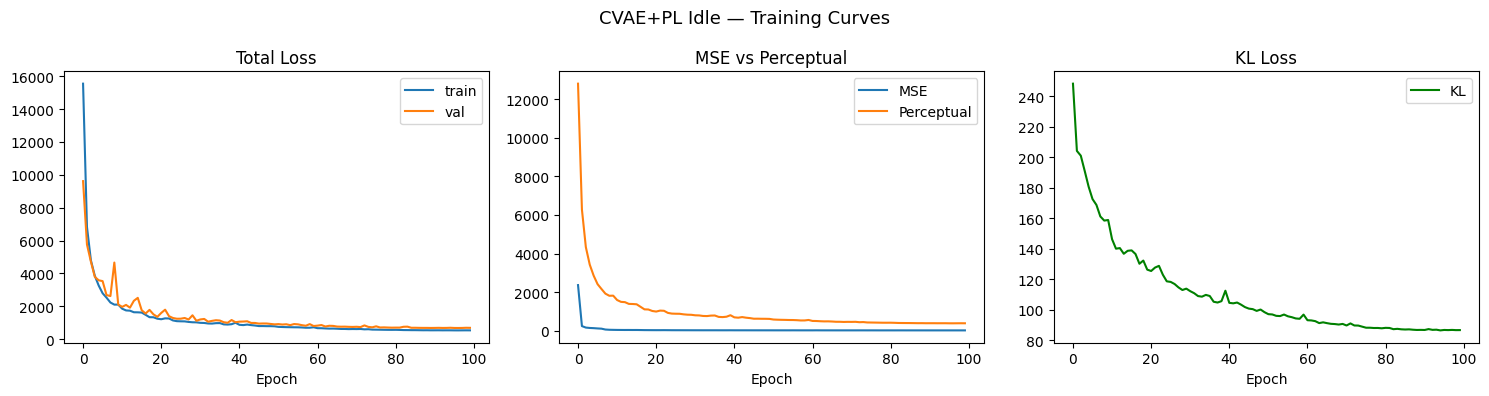

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'],     label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['mse'],  label='MSE')
axes[1].plot(history['perc'], label='Perceptual')
axes[1].set_title('MSE vs Perceptual'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['kl'], label='KL', color='green')
axes[2].set_title('KL Loss'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('CVAE+PL Idle — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

## 9. 생성 샘플 시각화

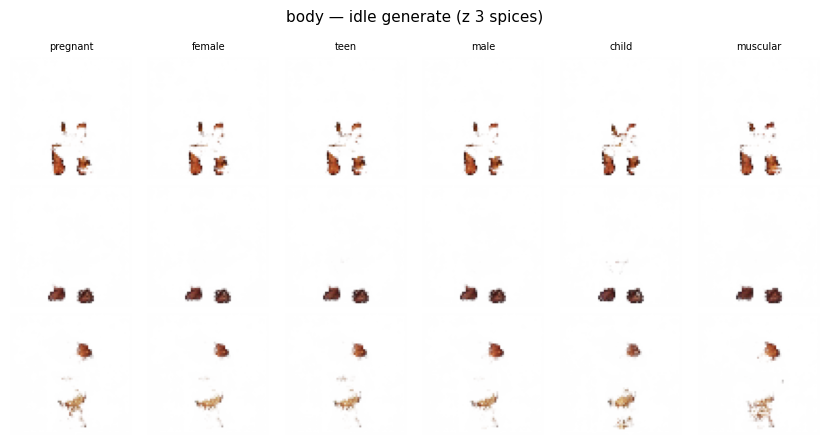

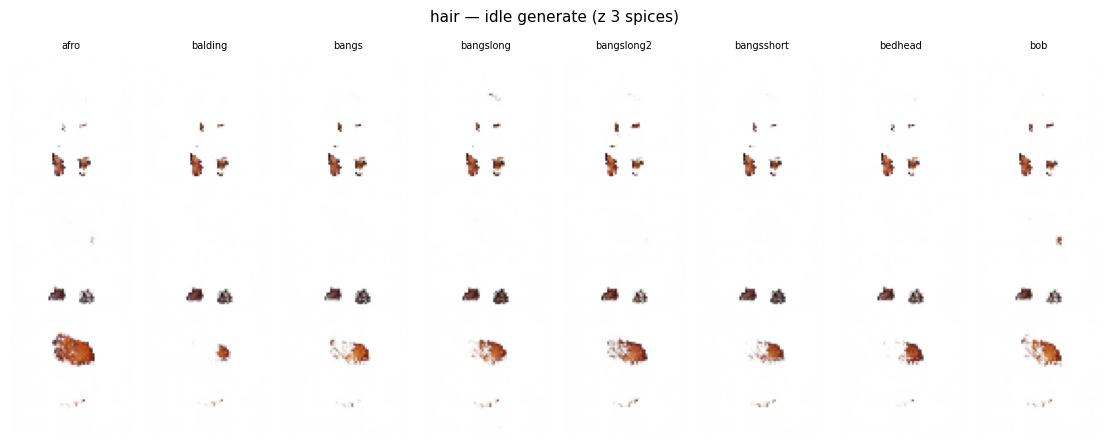

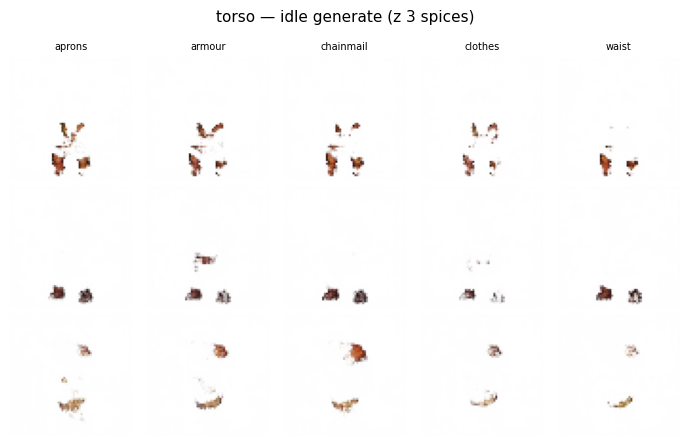

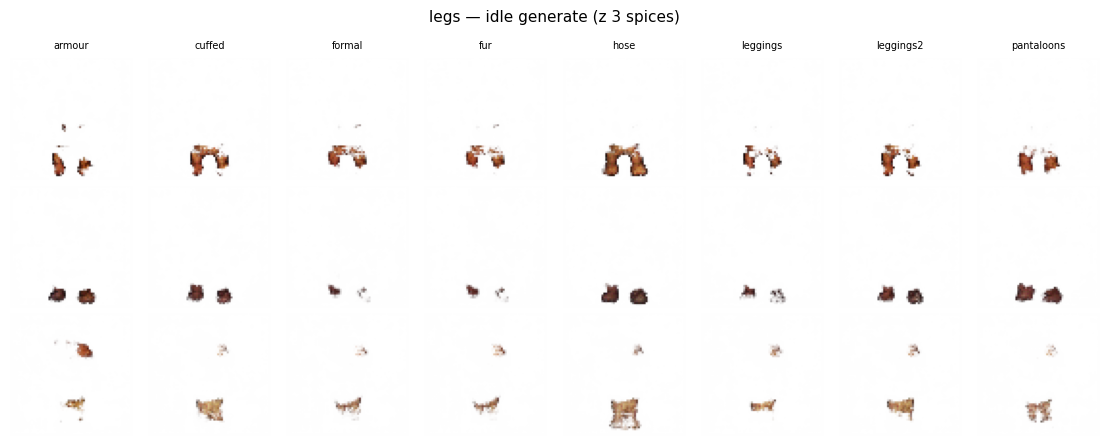

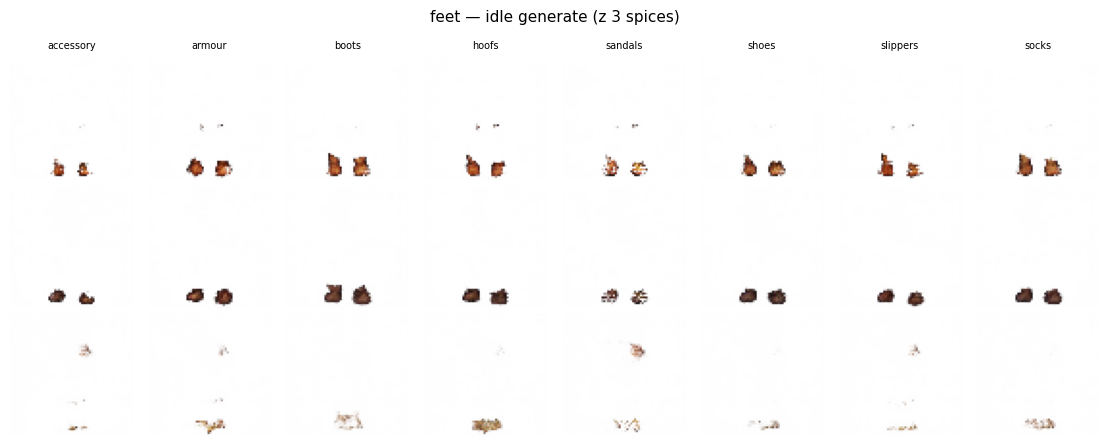

In [26]:
def composite(arr):
    """(H,W,4) ndarray → white-composited RGB ndarray"""
    rgb, a = arr[:, :, :3], arr[:, :, 3:]
    return np.clip(rgb * a + (1 - a), 0, 1)


# 카테고리별 랜덤 샘플 생성
SHOW_CATS = {
    'body' : [n for n in label_names if n.startswith('body_')],
    'hair' : [n for n in label_names if n.startswith('hair_')][:8],
    'torso': [n for n in label_names if n.startswith('torso_')],
    'legs' : [n for n in label_names if n.startswith('legs_')][:8],
    'feet' : [n for n in label_names if n.startswith('feet_')],
}

N_Z = 3
torch.manual_seed(0)
z_samples = torch.randn(N_Z, LATENT_DIM).to(DEVICE)

model.eval()
for cat_name, cat_labels in SHOW_CATS.items():
    n_labels = len(cat_labels)
    fig, axes = plt.subplots(N_Z, n_labels, figsize=(n_labels * 1.4, N_Z * 1.5))
    if N_Z == 1: axes = axes[np.newaxis, :]
    if n_labels == 1: axes = axes[:, np.newaxis]

    with torch.no_grad():
        for zi in range(N_Z):
            for li, lname in enumerate(cat_labels):
                idx = label_map[lname]
                c   = F.one_hot(torch.tensor([idx]), NUM_CLASSES).float().to(DEVICE)
                img = model.decoder(z_samples[zi:zi+1], c)
                arr = img[0].cpu().permute(1, 2, 0).numpy()
                axes[zi, li].imshow(composite(arr))
                axes[zi, li].axis('off')
                if zi == 0:
                    axes[zi, li].set_title(lname.split('_', 1)[1], fontsize=7)

    plt.suptitle(f'{cat_name} — idle generate (z 3 spices)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 10. 체크포인트 저장 & 요약

In [27]:
CFG['label_map']   = label_map
CFG['label_names'] = label_names
CFG['categories']  = ['body'] + LAYER_CATS

with open(CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)

print('저장 완료:', CKPT_DIR)
for p in sorted(CKPT_DIR.iterdir()):
    print(f'  {p.name:30s}  {p.stat().st_size/1024/1024:.2f} MB')

print()
print('=== 학습 요약 ===')
print(f'총 클래스   : {NUM_CLASSES}')
print(f'총 샘플     : {len(samples):,}')
print(f'best val_loss: {best_val:.4f}')
print(f'에폭        : {len(history["loss"])}/{EPOCHS}')
print()
print('카테고리별 클래스 수:')
for cat in ['body'] + LAYER_CATS:
    n = sum(1 for n in label_names if n.startswith(cat + '_'))
    print(f'  {cat:10s}: {n}')

저장 완료: checkpoints_cvae_pl_idle_pt
  best.pt                         12.79 MB
  config.json                     0.00 MB

=== 학습 요약 ===
총 클래스   : 89
총 샘플     : 32,574
best val_loss: 676.8790
에폭        : 100/100

카테고리별 클래스 수:
  body      : 6
  hair      : 58
  torso     : 5
  legs      : 12
  feet      : 8
